In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from config import *
from SMJP import (
    sparse_mc, get_y_uniform, 
    make_discretized_xi, make_discretized_eta
)
from utils import load_saved_path
from filter import Filter
from plots import plot_theta, plot_y, plot_obs

In [10]:
load_path = False
exp_id = 'non_intersecting_intervals'

In [11]:
if load_path:
    theta, y, t, theta_est, y_est, dxi, deta = load_saved_path(exp_id)
else:
    theta, y, t = sparse_mc(p0, Lambda, lam, T, get_y_uniform, y_intervals)
    dxi = make_discretized_xi(t_net_filtering, g, sigma, theta, y, t)
    deta = make_discretized_eta(t_net_filtering, h, theta, y, t)

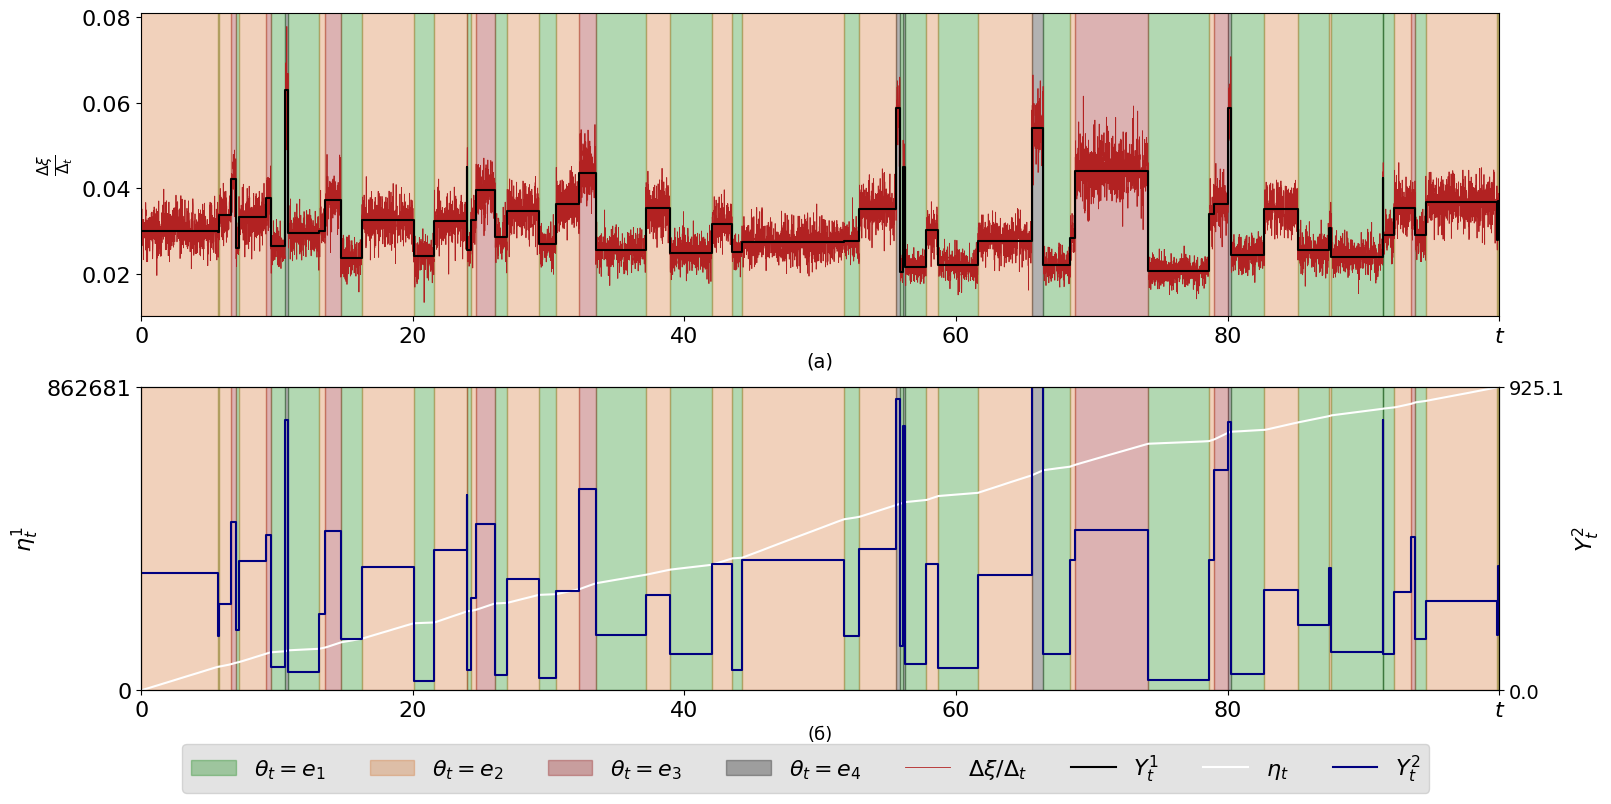

In [12]:
fig, ax = plot_obs(theta, y, t, dxi, deta)

plt.show()

In [13]:
if not load_path:

    tmp = np.stack([sigma(-1, M_net, -1)**2, h(-1, M_net, -1)], axis=-1)
    F = np.repeat(tmp[np.newaxis, ...], N, axis=0)
    tmp = np.stack([g(-1, M_net, -1), h(-1, M_net, -1)], axis=-1)
    G = np.repeat(tmp[np.newaxis, ...], N, axis=0)

    filter = Filter(
        p0[:, np.newaxis] * pi_uniform, 
        pi_uniform, M_net, F, G,
        N, Lambda, ht, delta
    )

    est = filter.estimate()
    theta_est = [est[0]]
    y_est = [est[1]]

    for i, obs in enumerate(tqdm(np.stack([dxi[1:100], deta[1:100]], axis=-1)), start=1):
        filter.update(obs)
        est = filter.estimate()
        if np.any(np.isnan(est[0])) or np.any(np.isnan(est[1])):
            print(f'nan on {i}-th iter')
            break
        theta_est.append(est[0])
        y_est.append(est[1])
    
    theta_est = np.array(theta_est)
    y_est = np.array(y_est)

  0%|          | 0/99 [00:00<?, ?it/s]

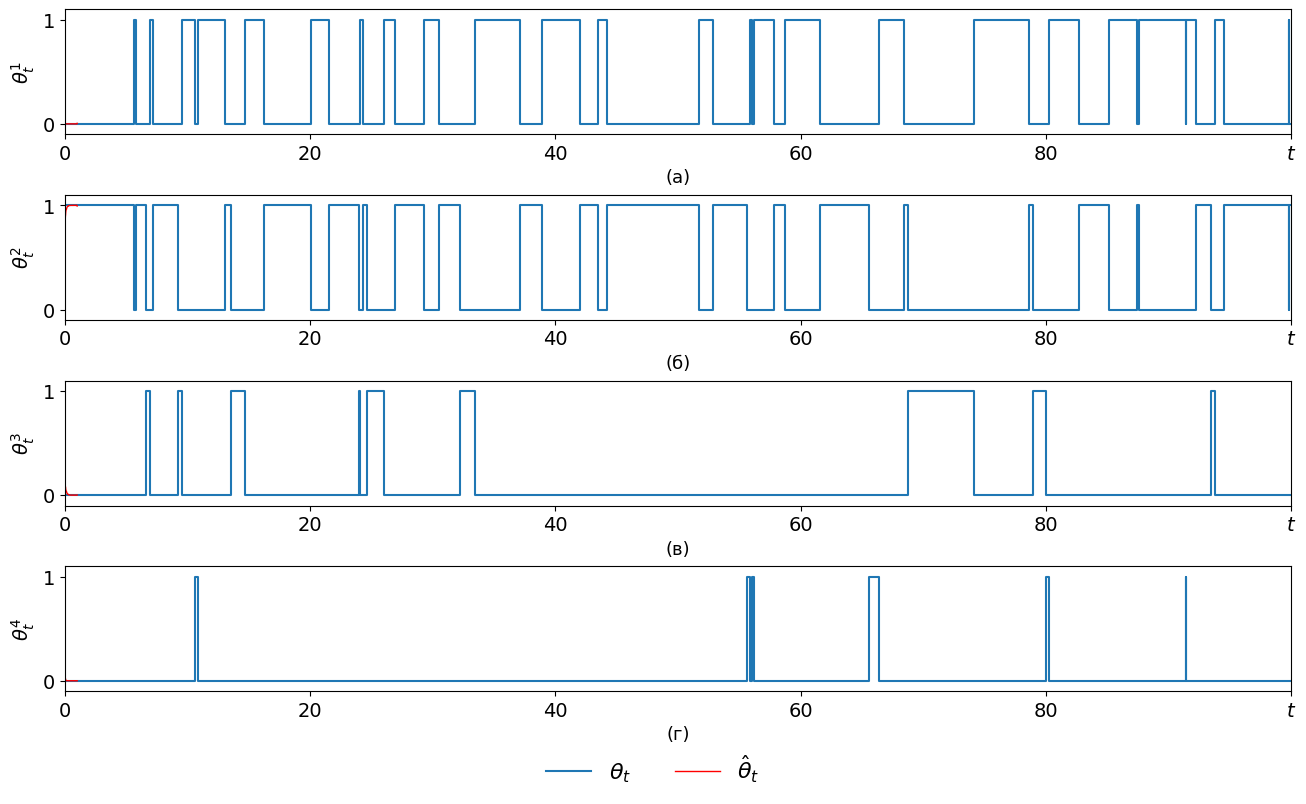

In [14]:
fig, ax = plot_theta(theta, t, theta_est)

plt.show()

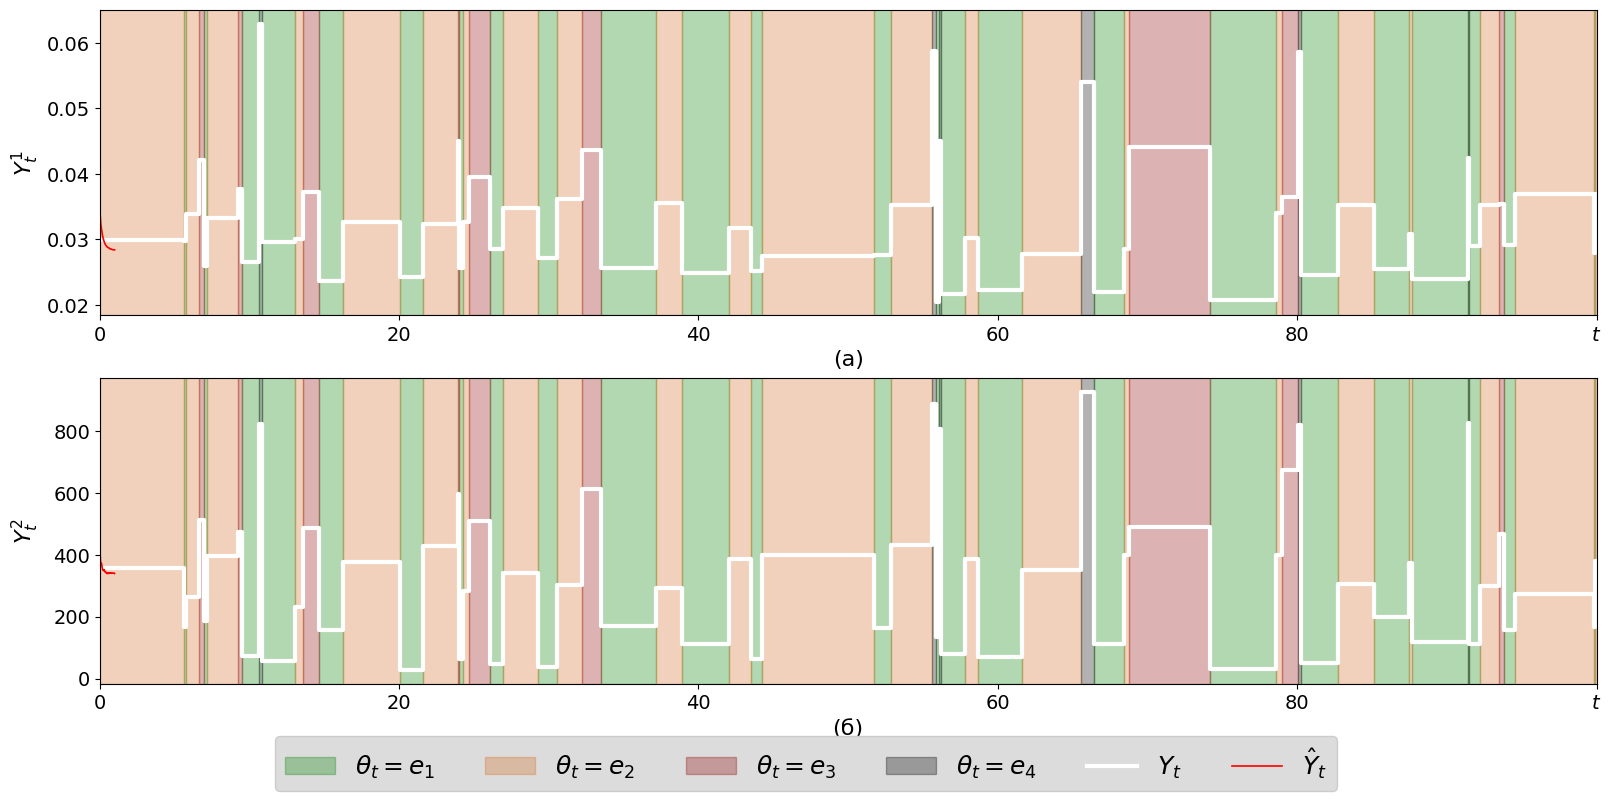

In [15]:
fig, ax = plot_y(theta, y, t, y_est)

plt.show()

In [16]:
# with open('saved_path/theta_est.pkl', 'wb') as f:
#     pickle.dump(theta_est, f)
# with open('saved_path/y_est.pkl', 'wb') as f:
#     pickle.dump(y_est, f)
# with open('saved_path/theta.pkl', 'wb') as f:
#     pickle.dump(theta, f)
# with open('saved_path/y.pkl', 'wb') as f:
#     pickle.dump(y, f)
# with open('saved_path/t.pkl', 'wb') as f:
#     pickle.dump(t, f)